# P3 · 01 — Quantile regression & calibration

To predict the τ-quantile (e.g. the 5th percentile), you minimise the **pinball
(quantile) loss**, which penalises under- and over-prediction *asymmetrically*:

$$L_\tau(y,\hat q)=\max\big(\tau(y-\hat q),\ (\tau-1)(y-\hat q)\big).$$

For τ=0.5 it's symmetric (→ the median); for τ=0.95 it punishes under-prediction
19× harder than over-prediction, pushing the estimate up into the tail.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import classical as C, probabilistic as P
q = data.load_quarterly(); y = q["gdp_nsa"]

### The pinball loss, drawn

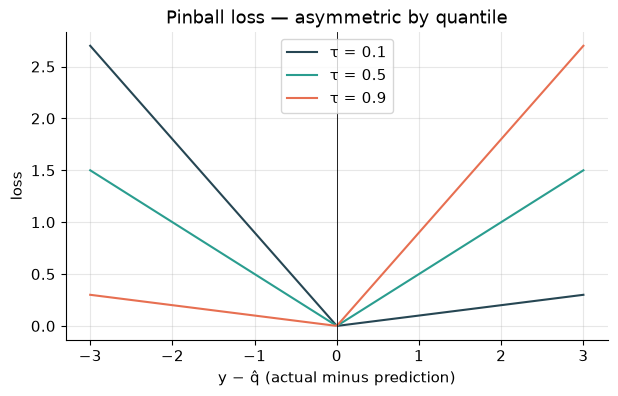

In [2]:
err = np.linspace(-3, 3, 200)
fig, ax = plt.subplots(figsize=(7, 4))
for tau, col in [(0.1, "#264653"), (0.5, "#2a9d8f"), (0.9, "#e76f51")]:
    loss = np.maximum(tau * err, (tau - 1) * err)
    ax.plot(err, loss, color=col, label=f"τ = {tau}")
ax.set(title="Pinball loss — asymmetric by quantile", xlabel="y − q̂ (actual minus prediction)",
       ylabel="loss"); ax.legend(); ax.axvline(0, color="k", lw=0.6); plt.show()

### Quantile crossing — and the fix

Quantiles fit **independently** can come out **non-monotone**: a predicted 90%
value below the 50% value. Nonsensical, and common with small data. The standard
fix is to **sort** the quantile predictions at each time point (isotonic / rearrange).

In [3]:
from lightgbm import LGBMRegressor
from src import features as F, ml
X, ytar = F.build_supervised(np.log(y), target="growth")
taus = [0.1, 0.3, 0.5, 0.7, 0.9]
preds = np.column_stack([
    LGBMRegressor(objective="quantile", alpha=t, **ml.DEFAULT_PARAMS).fit(X, ytar).predict(X)
    for t in taus])
crossings = int((np.diff(preds, axis=1) < 0).sum())
preds_sorted = np.sort(preds, axis=1)        # enforce monotonicity row-wise
print(f"raw quantile crossings: {crossings}  ->  after sorting: "
      f"{int((np.diff(preds_sorted, axis=1) < 0).sum())}")

raw quantile crossings: 37  ->  after sorting: 0


### The calibration (reliability) diagram

The acid test: for each nominal level, what fraction of actuals actually fall inside?
Plot **nominal vs empirical coverage** — the diagonal is perfect. We build honest
out-of-sample intervals with **split conformal** (calibrate residual quantiles on
earlier folds, measure coverage on later ones) across several levels.

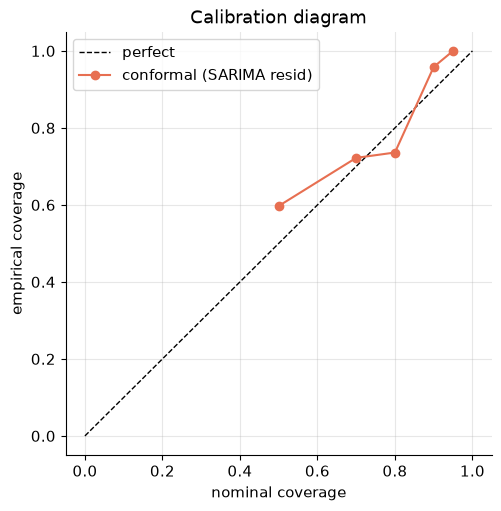

nominal : [0.5, 0.7, 0.8, 0.9, 0.95]
empirical: [0.6, 0.72, 0.74, 0.96, 1.0]


In [4]:
pf = C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4))
res = P.backtest_residuals(y, pf, initial=40, h=4, step=1, use_log=True)
cutoffs = np.sort(res.cutoff_idx.unique()); split = cutoffs[int(len(cutoffs) * 0.6)]
cal, test = res[res.cutoff_idx < split], res[res.cutoff_idx >= split]

levels = [0.5, 0.7, 0.8, 0.9, 0.95]
emp = []
for lv in levels:
    qmap = cal.groupby("step_ahead")["resid"].apply(lambda r: np.quantile(np.abs(r), lv))
    t = test.copy(); t["hw"] = t.step_ahead.map(qmap)
    lo, hi = t.y_pred * np.exp(-t.hw), t.y_pred * np.exp(t.hw)
    emp.append(P.coverage(t.y_true, lo, hi))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.plot(levels, emp, "o-", color="#e76f51", label="conformal (SARIMA resid)")
ax.set(title="Calibration diagram", xlabel="nominal coverage", ylabel="empirical coverage")
ax.legend(); plt.show()
print("nominal :", levels)
print("empirical:", [round(e, 2) for e in emp])

A well-calibrated method hugs the diagonal (or sits **just above** it — slightly
conservative is safe). Conformal lands there *by construction*, which is exactly why
we reach for it next.

---
**Next (02):** **conformal prediction** — distribution-free coverage guarantees —
and **adaptive conformal inference** for when time breaks the assumptions.